### importing dependencies


In [7]:
%matplotlib inline
import pandas as pd
import numpy as np
import geopandas as gpd
import shapely.wkt as wkt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from palettable.colorbrewer.sequential import Oranges_9, YlGn_9
from matplotlib.patches import Patch

from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 4)

In [23]:
df = pd.read_csv("Seating_Locations_20260319.csv")

### datasheet acknowledgement


In [14]:
df

,the_geom,BoroCode,BoroName,BoroCD,CounDist,AssemDist,StSenDist,CongDist,Category,Nearest_Add,...,Asset_ID,Asset_Subtype,Latitude,Longitude,SiteID,NTAName,FEMAFldz,FEMAFldT,HrcEvac,geometry
0,POINT (-73.77764762515179 40.714010735199224),4,Queens,412,23,29,11,5,NaN,184-06 Hillside Avenue,...,Color: Black (),BACKLESS 2.0,40.714019,-73.777649,SEAT.2025.0602,Jamaica,X,AREA OF MINIMAL FLOOD HAZARD,X,POINT (-73.77764762515179 40.714010735199224)
1,POINT (-73.97171956435525 40.68020474857601),3,Brooklyn,308,35,44,25,10,NaN,549 Bergen Street,...,Color: Black (BL2-2023-1803),BACKLESS 2.0,40.680213,-73.971721,SEAT.2023.0699,Prospect Heights,X,AREA OF MINIMAL FLOOD HAZARD,X,POINT (-73.97171956435525 40.68020474857601)
2,POINT (-73.98617714651992 40.74000423163591),1,Manhattan,105,2,74,59,12,NaN,100 E 23rd Street,...,Color: Silver (BB1-2013-1108),BACKED 1.0,40.740012,-73.986179,SEAT.2013.0511,Gramercy,X,AREA OF MINIMAL FLOOD HAZARD,6,POINT (-73.98617714651992 40.74000423163591)
3,POINT (-73.93507363564494 40.84643419697625),1,Manhattan,112,10,72,31,13,NaN,586 W 177th Street,...,Color: Silver (BB1-2014-1839),BACKED 1.0,40.846442,-73.935075,SEAT.2014.0364,Washington Heights (South),X,AREA OF MINIMAL FLOOD HAZARD,X,POINT (-73.93507363564494 40.84643419697625)
4,POINT (-73.92876457432111 40.65217538214825),3,Brooklyn,317,41,58,20,9,NaN,5149 Church Avenue,...,Color: Silver (BL1-2012-0148),BACKLESS 1.0,40.652184,-73.928766,SEAT.2012.0083,East Flatbush-Rugby,X,AREA OF MINIMAL FLOOD HAZARD,6,POINT (-73.92876457432111 40.65217538214825)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,POINT (-73.96799756583864 40.79193867736347),1,Manhattan,107,6,69,47,12,NaN,703 Columbus Avenue,...,Color: Silver (BB1-2015-1886),BACKED 1.0,40.791947,-73.967999,SEAT.2015.0089,Upper West Side (Central),X,AREA OF MINIMAL FLOOD HAZARD,X,POINT (-73.96799756583864 40.79193867736347)
3364,POINT (-73.88478237943959 40.74579184780445),4,Queens,404,25,39,13,6,NaN,80-98 41st Avenue,...,Color: Silver (BB2-2017-0143),BACKED 2.0,40.745800,-73.884784,SEAT.2017.0131,Elmhurst,X,AREA OF MINIMAL FLOOD HAZARD,X,POINT (-73.88478237943959 40.74579184780445)
3365,POINT (-73.91634557334002 40.816766720137885),2,Bronx,201,17,84,29,15,NaN,2882 3 Avenue,...,Color: Leaning Bar (LB-EMP2020-0028),LEANING BAR,40.816775,-73.916347,SEAT.2023.0050,Melrose,X,AREA OF MINIMAL FLOOD HAZARD,6,POINT (-73.91634557334002 40.816766720137885)
3366,POINT (-73.92120202818882 40.66049746757816),3,Brooklyn,317,41,58,19,9,NaN,1123 Clarkson Avenue,...,Color: Silver (BL1-2015-0755),BACKLESS 1.0,40.660506,-73.921203,SEAT.2015.0039,East Flatbush-Remsen Village,X,AREA OF MINIMAL FLOOD HAZARD,6,POINT (-73.92120202818882 40.66049746757816)


In [37]:
df["Asset_Subtype"].tolist()  # .list > is not working in this envrionment?

['BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKLESS 1.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKLESS 1.0',
 'BACKED 2.0',
 'BACKLESS 1.0',
 'BACKED 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'LEANING BAR',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 1.0',
 'LEANING BAR',
 'BACKLESS 1.0',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKED 2.0',
 'LEANING BAR',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKED 2.0',
 'BACKED 1.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKLESS 1.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'LEANING BAR',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKLESS 1.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKLESS 1.0',
 'BACKED 1.0',
 'BACKED 1.0',
 

In [31]:
df["Asset_Subtype"].value_counts()

Asset_Subtype
BACKLESS 2.0     972
BACKED 1.0       969
BACKED 2.0       687
BACKLESS 1.0     412
LEANING BAR      293
WORLDS FAIR       28
UNKNOWN BENCH      3
Name: count, dtype: int64

### simple analysis with charts


<Axes: >

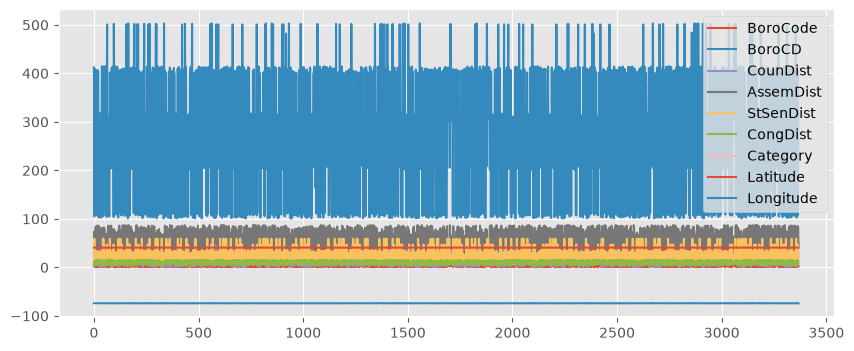

In [18]:
df.plot()  # useless data

<Axes: xlabel='Asset_Subtype'>

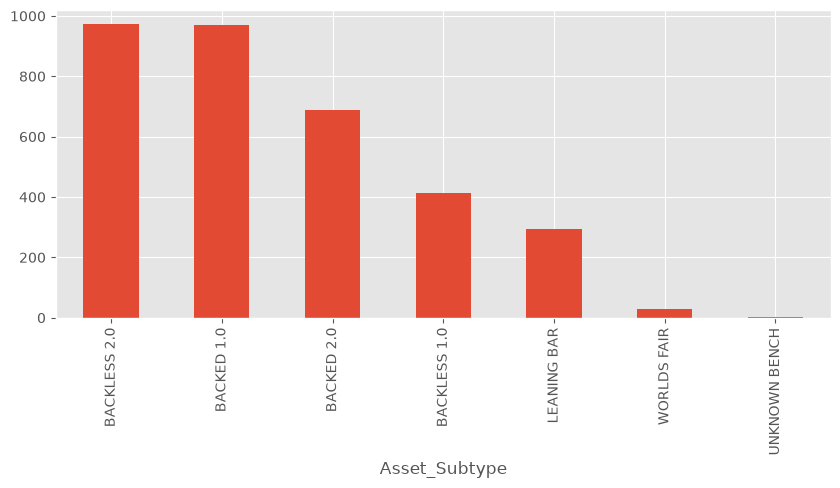

In [32]:
df_design = df["Asset_Subtype"].value_counts()
df_design.plot(kind="bar")

<Axes: >

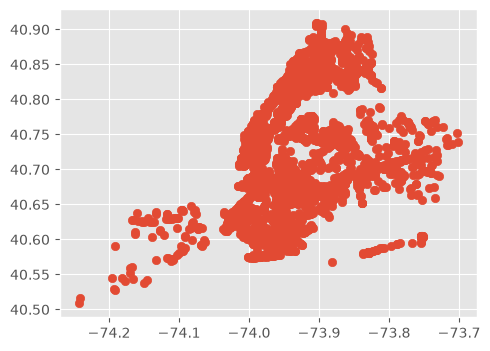

In [19]:
gdf.plot()  # this already shows the nyc map

### geometry/mapping analysis


In [33]:
df["geometry"] = df["the_geom"].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

In [34]:
gdf["longitude"] = gdf.geometry.x
gdf["latitude"] = gdf.geometry.y

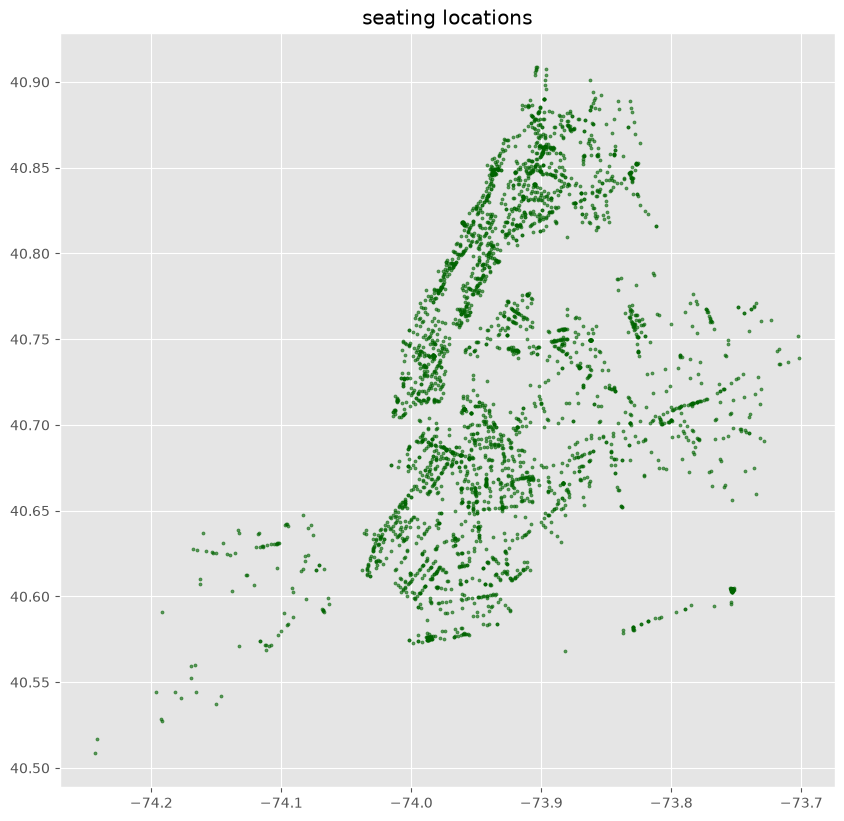

In [36]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, markersize=5, color="darkgreen", alpha=0.6)
ax.set_title("seating locations")
plt.show()

In [42]:
seating_data = gpd.read_file("Seating_Locations_20260319.csv")

In [43]:
seating_data.head()

,the_geom,BoroCode,BoroName,BoroCD,CounDist,AssemDist,StSenDist,CongDist,Category,Nearest_Add,...,Installation Date,Asset_ID,Asset_Subtype,Latitude,Longitude,SiteID,NTAName,FEMAFldz,FEMAFldT,HrcEvac
0,POINT (-73.77764762515179 40.714010735199224),4,Queens,412,23,29,11,5,,184-06 Hillside Avenue,...,09/25/2025,Color: Black (),BACKLESS 2.0,40.714019,-73.777649,SEAT.2025.0602,Jamaica,X,AREA OF MINIMAL FLOOD HAZARD,X
1,POINT (-73.97171956435525 40.68020474857601),3,Brooklyn,308,35,44,25,10,,549 Bergen Street,...,08/16/2023,Color: Black (BL2-2023-1803),BACKLESS 2.0,40.680213,-73.971721,SEAT.2023.0699,Prospect Heights,X,AREA OF MINIMAL FLOOD HAZARD,X
2,POINT (-73.98617714651992 40.74000423163591),1,Manhattan,105,2,74,59,12,,100 E 23rd Street,...,12/04/2013,Color: Silver (BB1-2013-1108),BACKED 1.0,40.74001249,-73.98617859,SEAT.2013.0511,Gramercy,X,AREA OF MINIMAL FLOOD HAZARD,6
3,POINT (-73.93507363564494 40.84643419697625),1,Manhattan,112,10,72,31,13,,586 W 177th Street,...,12/04/2014,Color: Silver (BB1-2014-1839),BACKED 1.0,40.84644248,-73.93507507,SEAT.2014.0364,Washington Heights (South),X,AREA OF MINIMAL FLOOD HAZARD,X
4,POINT (-73.92876457432111 40.65217538214825),3,Brooklyn,317,41,58,20,9,,5149 Church Avenue,...,07/18/2012,Color: Silver (BL1-2012-0148),BACKLESS 1.0,40.65218363,-73.928766,SEAT.2012.0083,East Flatbush-Rugby,X,AREA OF MINIMAL FLOOD HAZARD,6


TypeError: no numeric data to plot